In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [15]:
# === KERAS BUG'I İÇİN "MONKEY PATCH" YAMASI ===
# Keras'ın Dense (Karar) katmanının başlatıcı fonksiyonunu yedekliyoruz
original_dense_init = tf.keras.layers.Dense.__init__

def patched_dense_init(self, *args, **kwargs):
    # Eğer Keras içine yanlışlıkla 'quantization_config' koymuşsa, onu anında sil!
    kwargs.pop('quantization_config', None) 
    # Sonra Keras'ın orijinal fonksiyonunu hiçbir şey olmamış gibi çalıştır
    original_dense_init(self, *args, **kwargs)

# Keras'ın beynindeki orijinal fonksiyonu bizim yamalı fonksiyonumuzla değiştiriyoruz
tf.keras.layers.Dense.__init__ = patched_dense_init

In [16]:
MODEL_PATH = r"C:\Users\fatih\Desktop\Masaustu\Programming\Projects\auto-rigging\ml_pipeline\saved_models\auto_rigger_efficientnet.keras"

TEST_DIR = r"C:\Users\fatih\Desktop\Masaustu\Programming\Projects\auto-rigging\dataset\test_renders"

CLASS_NAMES = ['humanoid', 'quadruped']

✅ Model Yüklendi

📸 Toplam 48 adet test resmi bulundu. Tahminler başlıyor...



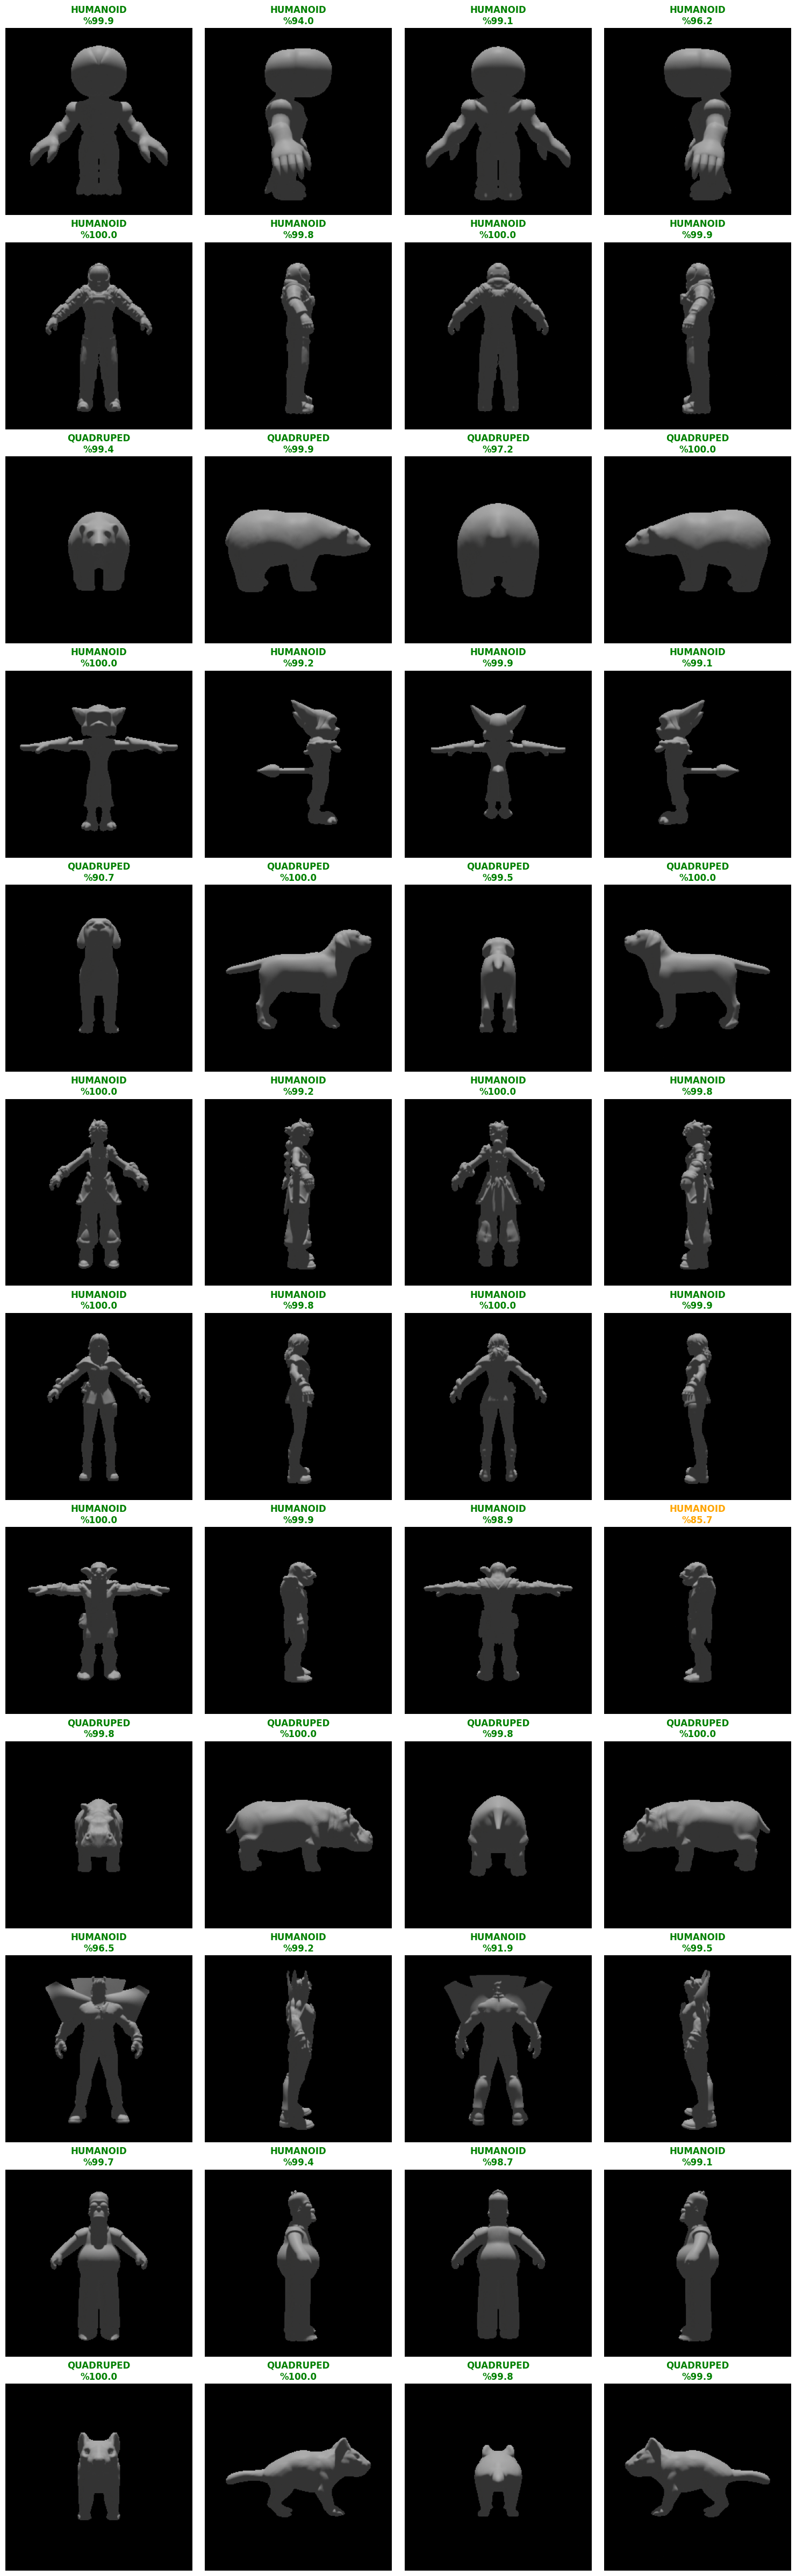

In [17]:
model = load_model(MODEL_PATH, compile=False)
print("✅ Model Yüklendi\n")

# Klasördeki sadece resim dosyalarını bul
test_images = [f for f in os.listdir(TEST_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]


if not test_images:
    print("❌ Test klasöründe hiç resim bulunamadı! Lütfen yeni render'ları klasöre ekleyin.")
else:
    print(f"📸 Toplam {len(test_images)} adet test resmi bulundu. Tahminler başlıyor...\n")

    cols = 4
    rows = int(np.ceil(len(test_images) / cols))
    
    plt.figure(figsize=(15, 4 * rows))
    
    for i, img_name in enumerate(test_images):
        img_path = os.path.join(TEST_DIR, img_name)
        
        # 1. Resmi yükle (256x256 formatında)
        img = image.load_img(img_path, target_size=(256, 256))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) 
        
        # 2. Tahmin yap
        predictions = model.predict(img_array, verbose=0)[0]
        
        predicted_index = np.argmax(predictions)
        predicted_class = CLASS_NAMES[predicted_index]
        confidence = predictions[predicted_index] * 100
        
        # 3. Ekrana Çizdirme
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        
        # Eğer yapay zeka %90'dan fazla eminse Yeşil, daha düşük bir ihtimal verirse Turuncu yazsın
        color = 'green' if confidence > 90.0 else 'orange'
        plt.title(f"{predicted_class.upper()}\n%{confidence:.1f}", color=color, fontweight='bold')
        
    # Resimlerin birbirine girmemesi için boşlukları ayarla ve göster
    plt.tight_layout()
    plt.show()
    
